TRECIA UZDUOTIS

Imports

In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Define the ticker symbol and time period

In [5]:
ticker = 'AAPL'
start_date = '2014-11-08'
end_date = '2017-11-08'

Download historical data from Yahoo Finance and flatten MultiIndex columns from yfinance

In [6]:
data = yf.download(ticker, start=start_date, end=end_date, interval='1d')
data.columns = data.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


Set innitial values

In [7]:
#trading cost percentage
trade_cost = 0.001

# Initial non-optimized parameters
initial_take_profit = 0.05  # 5% take profit
initial_stop_loss = 0.02    # 2% stop loss

Optimization parameters

In [8]:
take_profit_range = np.arange(0.03, 0.1, 0.01)  # Range for take profit (3% to 10%)
stop_loss_range = np.arange(0.01, 0.05, 0.01)   # Range for stop loss (1% to 5%)

Calculate Bollinger Bands outside the function

In [9]:
data['20_MA'] = data['Close'].rolling(window=20).mean()
data['20_STD'] = data['Close'].rolling(window=20).std()
data['Upper_Band'] = data['20_MA'] + (2 * data['20_STD'])
data['Lower_Band'] = data['20_MA'] - (2 * data['20_STD'])

# Initialize columns for signals and exit type in the main DataFrame
data['Signal'] = 0
data['Exit_Type'] = ''

Function to calculate cumulative returns for given take profit and stop loss

In [10]:
def calculate_strategy(data, take_profit, stop_loss):
    position = 0
    buy_price = 0
    
    for i in range(1, len(data)):
        if position == 0:
            # Look for a buy signal (price below lower Bollinger Band)
            close_price = float(data['Close'].iloc[i])
            lower_band = float(data['Lower_Band'].iloc[i])
            if close_price < lower_band:
                data.at[data.index[i], 'Signal'] = 1  # Buy signal
                buy_price = close_price
                position = 1  # Enter position
        elif position == 1:
            # Check for take profit or stop loss
            close_price = float(data['Close'].iloc[i])
            if close_price >= buy_price * (1 + take_profit):
                data.at[data.index[i], 'Signal'] = -1  # Take profit (sell)
                data.at[data.index[i], 'Exit_Type'] = 'Take Profit'
                position = 0  # Exit position
            elif close_price <= buy_price * (1 - stop_loss):
                data.at[data.index[i], 'Signal'] = -1  # Stop loss (sell)
                data.at[data.index[i], 'Exit_Type'] = 'Stop Loss'
                position = 0  # Exit position

    # Calculate daily returns and apply trading costs
    data['Daily_Return'] = data['Close'].pct_change()
    data['Trade_Return'] = data['Daily_Return'] * data['Signal'].shift(1)
    data['Cost_Adjusted_Trade_Return'] = np.where(
        data['Signal'] != data['Signal'].shift(1),
        data['Trade_Return'] - trade_cost * abs(data['Trade_Return']),
        data['Trade_Return']
    )

    # Calculate cumulative returns for the strategy
    data['Cumulative_Strategy_Return'] = (1 + data['Cost_Adjusted_Trade_Return']).cumprod() - 1
    return data

Calculate non-optimized strategy returns

In [11]:
non_optimized_data = data.copy()
non_optimized_data = calculate_strategy(non_optimized_data, initial_take_profit, initial_stop_loss)

Perform grid search optimization for the best take profit and stop loss values

In [12]:
best_take_profit = 0
best_stop_loss = 0
best_return = -np.inf

for take_profit in take_profit_range:
    for stop_loss in stop_loss_range:
        temp_data = data.copy()
        temp_data = calculate_strategy(temp_data, take_profit, stop_loss)
        final_return = temp_data['Cumulative_Strategy_Return'].iloc[-1]
        if final_return > best_return:
            best_return = final_return
            best_take_profit = take_profit
            best_stop_loss = stop_loss

print(f"Optimized Take Profit: {best_take_profit*100}%")
print(f"Optimized Stop Loss: {best_stop_loss*100}%")
print(f"Best Cumulative Return: {best_return}")

Optimized Take Profit: 4.0%
Optimized Stop Loss: 1.0%
Best Cumulative Return: 0.10121459905101227


Run the strategy with the optimized parameters

In [13]:
optimized_data = data.copy()
optimized_data = calculate_strategy(optimized_data, best_take_profit, best_stop_loss)

Close Price with Upper and Lower Bollinger Bands

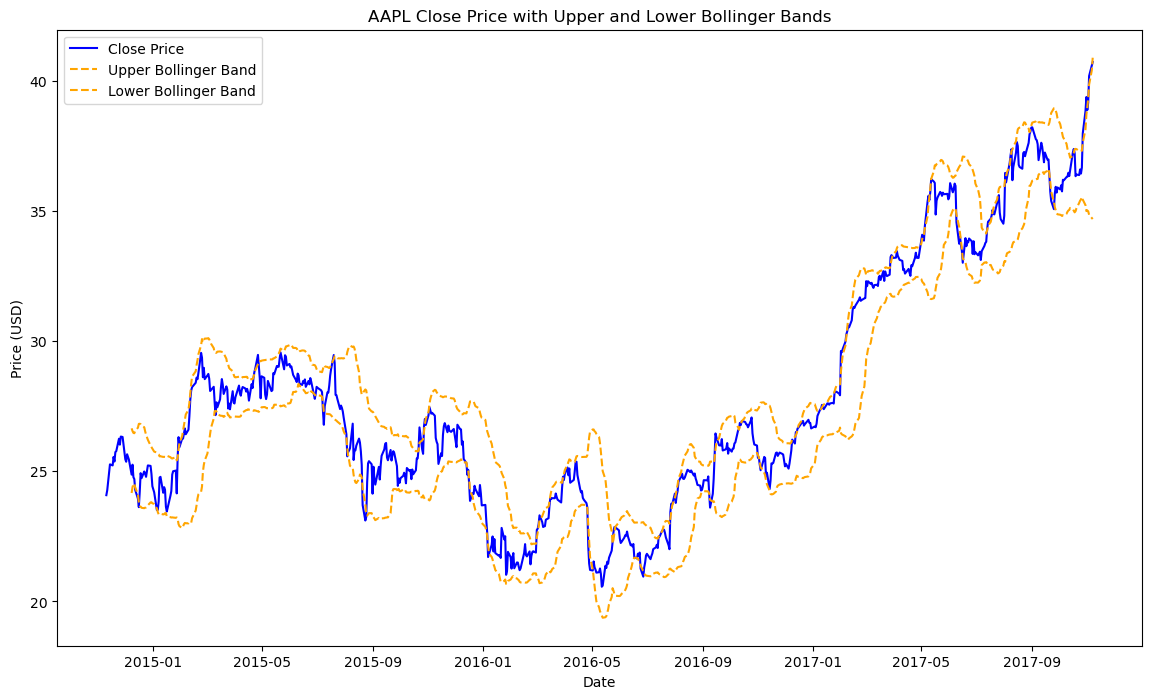

In [14]:
plt.figure(figsize=(14, 8))
plt.plot(data.index, data['Close'], label='Close Price', color='blue')
plt.plot(data.index, data['Upper_Band'], label='Upper Bollinger Band', linestyle='--', color='orange')
plt.plot(data.index, data['Lower_Band'], label='Lower Bollinger Band', linestyle='--', color='orange')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title(f'{ticker} Close Price with Upper and Lower Bollinger Bands')
plt.legend()
plt.show()

Buy and Sell Signals with Take Profit and Stop Loss Exits (without Bollinger Bands)

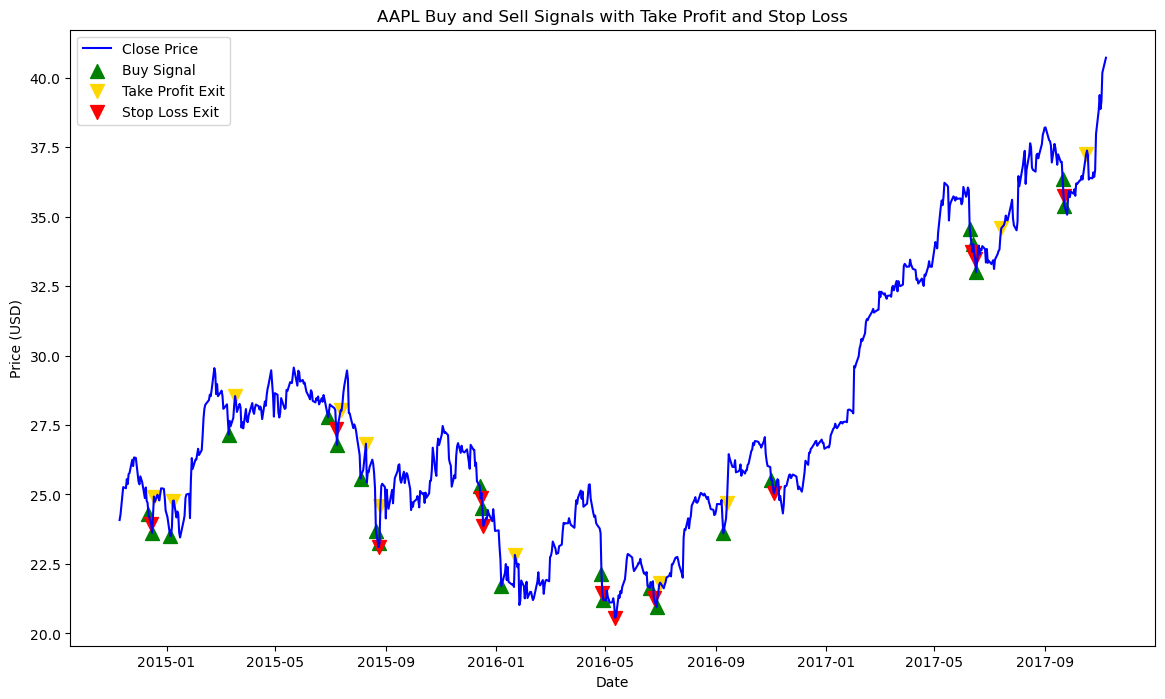

In [15]:
plt.figure(figsize=(14, 8))
plt.plot(data.index, data['Close'], label='Close Price', color='blue')

buy_signals = optimized_data[optimized_data['Signal'] == 1]
take_profit_exits = optimized_data[(optimized_data['Signal'] == -1) & (optimized_data['Exit_Type'] == 'Take Profit')]
stop_loss_exits = optimized_data[(optimized_data['Signal'] == -1) & (optimized_data['Exit_Type'] == 'Stop Loss')]

plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', label='Buy Signal', s=100)
plt.scatter(take_profit_exits.index, take_profit_exits['Close'], marker='v', color='gold', label='Take Profit Exit', s=100)
plt.scatter(stop_loss_exits.index, stop_loss_exits['Close'], marker='v', color='red', label='Stop Loss Exit', s=100)

plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title(f'{ticker} Buy and Sell Signals with Take Profit and Stop Loss')
plt.legend()
plt.show()

Optimized vs Non-Optimized Cumulative Returns for Strategy (Combined Profits and Losses)

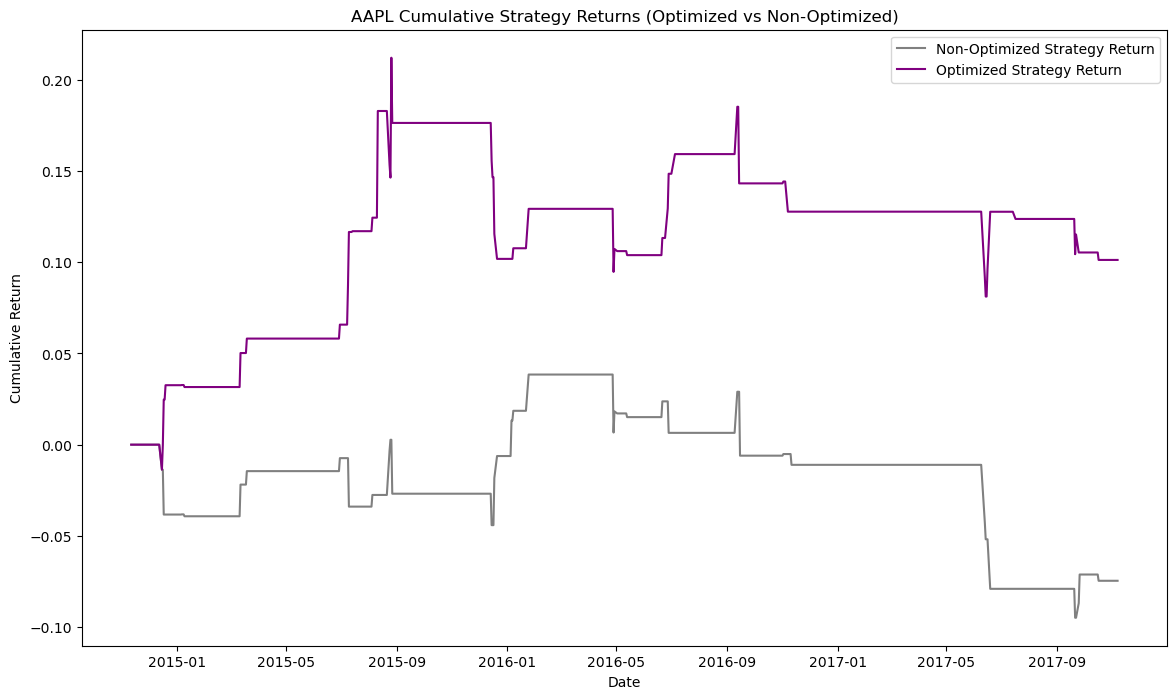

In [16]:
plt.figure(figsize=(14, 8))
plt.plot(non_optimized_data.index, non_optimized_data['Cumulative_Strategy_Return'], label='Non-Optimized Strategy Return', color='grey')
plt.plot(optimized_data.index, optimized_data['Cumulative_Strategy_Return'], label='Optimized Strategy Return', color='purple')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title(f'{ticker} Cumulative Strategy Returns (Optimized vs Non-Optimized)')
plt.legend()
plt.show()